In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import tqdm
import torchvision.datasets as datasets

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

# Part 1

## LLM Usage Statement

For this assignment, I used Claude Opus 4.6 to help clarify concepts and improve the formatting and presentation of the report.  

All core code was independently written and implemented by me.  

I hereby declare this statement to disclose the use of LLM assistance.

## Task 1.1

In [4]:
class TranslatedMNIST(Dataset):
    """
    Places MNIST digits on a larger canvas at either centered or random positions.
    
    Args:
        mnist_dataset: base MNIST dataset from torchvision
        canvas_size: size of the larger canvas (default 56)
        mode: 'centered' or 'translated'
    """
    def __init__(self, mnist_dataset, canvas_size=56, mode='centered'):
        self.mnist = mnist_dataset
        self.canvas_size = canvas_size
        self.mode = mode
        self.digit_size = 28
        self.max_offset = canvas_size - self.digit_size
        
        if mode == 'translated':
            rng = np.random.RandomState(42 if hasattr(mnist_dataset, 'train') else 123)
            self.offsets_x = rng.randint(0, self.max_offset + 1, size=len(mnist_dataset))
            self.offsets_y = rng.randint(0, self.max_offset + 1, size=len(mnist_dataset))
    
    def __len__(self):
        return len(self.mnist)
    
    def __getitem__(self, idx):
        img, label = self.mnist[idx]
        
        # Create blank canvas
        canvas = torch.zeros(1, self.canvas_size, self.canvas_size)
        
        if self.mode == 'centered':
            # Place digit in center
            offset = (self.canvas_size - self.digit_size) // 2
            canvas[:, offset:offset+self.digit_size, offset:offset+self.digit_size] = img
        else:
            # Place digit at random position
            ox = self.offsets_x[idx]
            oy = self.offsets_y[idx]
            canvas[:, oy:oy+self.digit_size, ox:ox+self.digit_size] = img
        
        return canvas, torch.tensor(label)

In [5]:
transform = transforms.Compose([transforms.ToTensor()])

mnist_train = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
mnist_test = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# Create four configurations
canvas_size = 64
centered_train   = TranslatedMNIST(mnist_train, canvas_size=canvas_size, mode='centered')
translated_train = TranslatedMNIST(mnist_train, canvas_size=canvas_size, mode='translated')
centered_test    = TranslatedMNIST(mnist_test,  canvas_size=canvas_size, mode='centered')
translated_test  = TranslatedMNIST(mnist_test,  canvas_size=canvas_size, mode='translated')

print(f"centered_train  : {len(centered_train)}, image shape: {centered_train[0][0].shape}")
print(f"translated_train: {len(translated_train)}")
print(f"centered_test   : {len(centered_test)}")
print(f"translated_test : {len(translated_test)}")

centered_train  : 60000, image shape: torch.Size([1, 64, 64])
translated_train: 60000
centered_test   : 10000
translated_test : 10000


### Visualize samples centered and translated versions of the same idx image

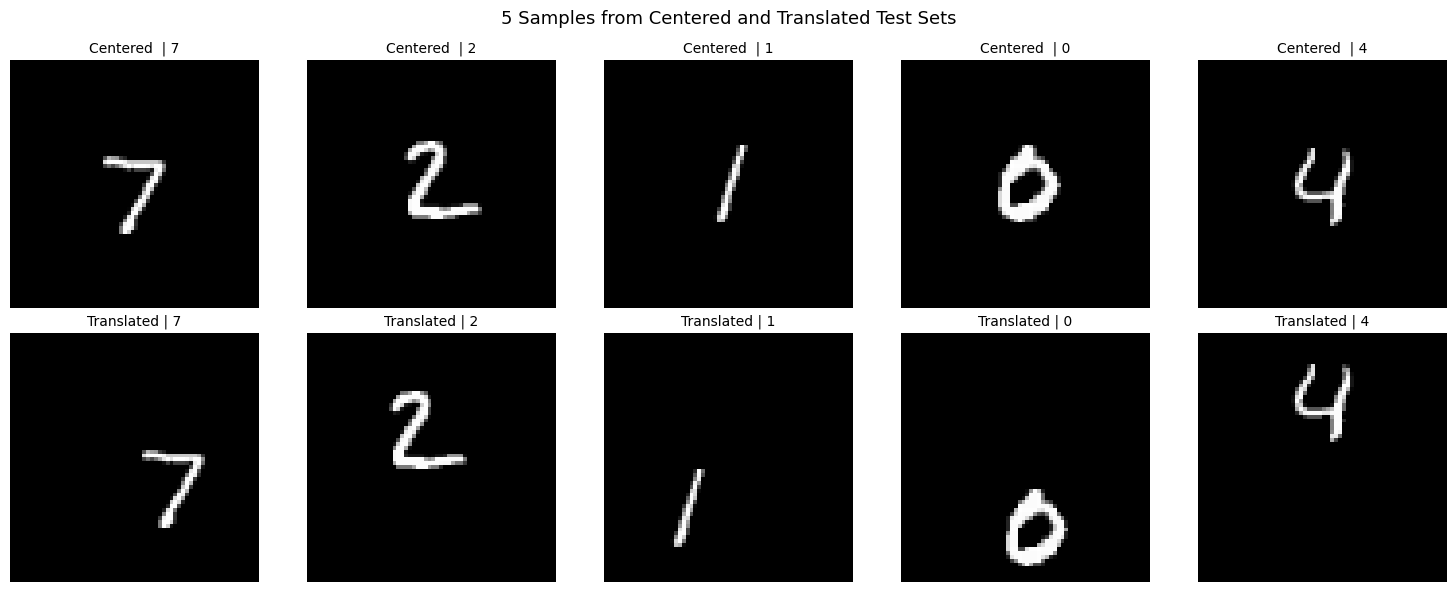

In [6]:
# Visualize 5 samples 
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    c_img, c_lbl = centered_test[i]
    axes[0, i].imshow(c_img.squeeze(), cmap='gray')
    axes[0, i].set_title(f'Centered  | {c_lbl.item()}', fontsize=10)
    axes[0, i].axis('off')

    t_img, t_lbl = translated_test[i]
    axes[1, i].imshow(t_img.squeeze(), cmap='gray')
    axes[1, i].set_title(f'Translated | {t_lbl.item()}', fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Centered',   fontsize=12)
axes[1, 0].set_ylabel('Translated', fontsize=12)
plt.suptitle('5 Samples from Centered and Translated Test Sets', fontsize=13)
plt.tight_layout()
plt.show()

## Task 1.2

In [7]:
class MLP(nn.Module):
    """Simple MLP classifier"""
    def __init__(self, input_size=64*64, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
    def get_hidden_features(self, x):
        """Extract the last hidden layer features (before classification head)."""
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

class SimpleCNN(nn.Module):
    """
    Convolutional Neural Network (CNN) classifier with global average pooling.

    Architecture:
        Input -> Conv1(5x5) -> ReLU -> MaxPool(2x2) ->
        Conv2(5x5) -> ReLU -> MaxPool(2x2) ->
        GlobalAvgPool -> FC(256) -> ReLU -> FC(num_classes)

    Key feature: Global Average Pooling allows this network to accept
    images of any size, making it more flexible than traditional CNNs.

    Args:
        num_classes: Number of output classes (default: 10 for MNIST)
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(64, 256)
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        # First convolutional block: Conv -> ReLU -> Pool
        x = self.conv1(x)          # (B, 1, H, W) -> (B, 32, H-4, W-4)
        x = F.relu(x)              # Apply ReLU activation
        x = self.pool1(x)          # (B, 32, H-4, W-4) -> (B, 32, (H-4)//2, (W-4)//2)
        
        # Second convolutional block: Conv -> ReLU -> Pool
        x = self.conv2(x)          # (B, 32, H', W') -> (B, 64, H'-4, W'-4)
        x = F.relu(x)              # Apply ReLU activation
        x = self.pool2(x)          # (B, 64, H'-4, W'-4) -> (B, 64, H'', W'')
        
        # Global average pooling: reduces any spatial size to 1x1
        x = self.global_pool(x)    # (B, 64, H'', W'') -> (B, 64, 1, 1)
        
        # Flatten: remove the spatial dimensions (1x1)
        x = x.view(x.size(0), -1) # (B, 64, 1, 1) -> (B, 64)
        
        # First fully connected layer with ReLU
        x = self.fc1(x)            # (B, 64) -> (B, 256)
        x = F.relu(x)              # Apply ReLU activation
        
        # Output layer (no activation - use with CrossEntropyLoss)
        x = self.fc2(x)            # (B, 256) -> (B, num_classes)
        
        return x
    
    def get_feature_maps(self, x):
        """
        Extract intermediate feature maps from convolutional layers.
        Returns fm1, fm1_pooled, fm2, fm2_pooled.
        """
        # First conv block
        fm1 = F.relu(self.conv1(x))    # after conv1, before pool
        fm1_pooled = self.pool1(fm1)   # after pool1

        # Second conv block
        fm2 = F.relu(self.conv2(fm1_pooled))  # after conv2, before pool
        fm2_pooled = self.pool2(fm2)           # after pool2

        return fm1, fm1_pooled, fm2, fm2_pooled
    
    def get_hidden_features(self, x):
        """
        Extract features from the last hidden layer (before classification).
        Returns hidden features of shape (batch_size, 256).
        """
        # Pass through all conv and pooling layers
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        # Global average pooling and flatten
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        # Last hidden layer (before output)
        x = F.relu(self.fc1(x))
        return x

# Quick sanity check
_mlp = MLP(input_size=canvas_size*canvas_size)
_cnn = SimpleCNN()
print(f"MLP parameters: {sum(p.numel() for p in _mlp.parameters()):,}")
print(f"CNN parameters: {sum(p.numel() for p in _cnn.parameters()):,}")
_dummy = torch.zeros(2, 1, canvas_size, canvas_size)
print(f"MLP output: {_mlp(_dummy).shape}")
print(f"CNN output: {_cnn(_dummy).shape}")

MLP parameters: 2,231,562
CNN parameters: 71,306
MLP output: torch.Size([2, 10])
CNN output: torch.Size([2, 10])


In [6]:
def train_model(model: nn.Module, train_loader: DataLoader, epochs: int = 10, lr: float = 0.001):
    """Train a model and return loss history."""
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    loss_history = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        avg_loss = running_loss / len(train_loader)
        acc = 100.0 * correct / total
        loss_history.append(avg_loss)
        print(f"  Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} Train Acc: {acc:.2f}%")
    
    return loss_history
    

In [7]:
def evaluate_model(model, test_loader):
    """Evaluate model accuracy on a test set."""
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return 100.0 * correct / total

## Task 1.3

In [8]:
BATCH_SIZE = 128
EPOCHS = 10

In [9]:
# ── Dataloaders ───────────────────────────────────────────────────────────────
def make_loader(ds, shuffle=True):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=2)

centered_train_loader   = make_loader(centered_train)
centered_test_loader    = make_loader(centered_test,    shuffle=False)
translated_train_loader = make_loader(translated_train)
translated_test_loader  = make_loader(translated_test,  shuffle=False)

# ── Train all 6 configurations ────────────────────────────────────────────────
results = {}

print("=" * 55)
print("1) MLP — train: Centered, test: Centered")
mlp_c = MLP(input_size=canvas_size*canvas_size)
train_model(mlp_c, centered_train_loader, epochs=EPOCHS)
results[('MLP','Centered','Centered')]    = evaluate_model(mlp_c, centered_test_loader)
results[('MLP','Centered','Translated')]  = evaluate_model(mlp_c, translated_test_loader)

print("=" * 55)
print("2) CNN — train: Centered, test: Centered")
cnn_c = SimpleCNN()
train_model(cnn_c, centered_train_loader, epochs=EPOCHS)
results[('CNN','Centered','Centered')]    = evaluate_model(cnn_c, centered_test_loader)
results[('CNN','Centered','Translated')]  = evaluate_model(cnn_c, translated_test_loader)

print("=" * 55)
print("3) MLP — train: Translated, test: Translated")
mlp_t = MLP(input_size=canvas_size*canvas_size)
train_model(mlp_t, translated_train_loader, epochs=EPOCHS)
results[('MLP','Translated','Translated')] = evaluate_model(mlp_t, translated_test_loader)

print("=" * 55)
print("4) CNN — train: Translated, test: Translated")
cnn_t = SimpleCNN()
train_model(cnn_t, translated_train_loader, epochs=EPOCHS)
results[('CNN','Translated','Translated')] = evaluate_model(cnn_t, translated_test_loader)

# ── Print table ───────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
order = [
    ('MLP','Centered',   'Centered'),
    ('MLP','Centered',   'Translated'),
    ('CNN','Centered',   'Centered'),
    ('CNN','Centered',   'Translated'),
    ('MLP','Translated', 'Translated'),
    ('CNN','Translated', 'Translated'),
]
print(f"{'Model':<6} {'Train Set':<12} {'Test Set':<12} {'Accuracy':>10}")
print("-" * 44)
for key in order:
    m, tr, te = key
    print(f"{m:<6} {tr:<12} {te:<12} {results[key]:>9.2f}%")

1) MLP — train: Centered, test: Centered


  Epoch [1/10] Loss: 0.2962 Train Acc: 91.55%


  Epoch [2/10] Loss: 0.1040 Train Acc: 96.84%


  Epoch [3/10] Loss: 0.0680 Train Acc: 97.91%


  Epoch [4/10] Loss: 0.0476 Train Acc: 98.51%


...

  Epoch [7/10] Loss: 0.1980 Train Acc: 94.16%


  Epoch [8/10] Loss: 0.1750 Train Acc: 94.78%


  Epoch [9/10] Loss: 0.1530 Train Acc: 95.34%


  Epoch [10/10] Loss: 0.1396 Train Acc: 95.77%



Model  Train Set    Test Set       Accuracy
--------------------------------------------
MLP    Centered     Centered         97.78%
MLP    Centered     Translated       12.65%
CNN    Centered     Centered         96.42%
CNN    Centered     Translated       91.09%
MLP    Translated   Translated       85.98%
CNN    Translated   Translated       95.49%


### Visualize feature maps

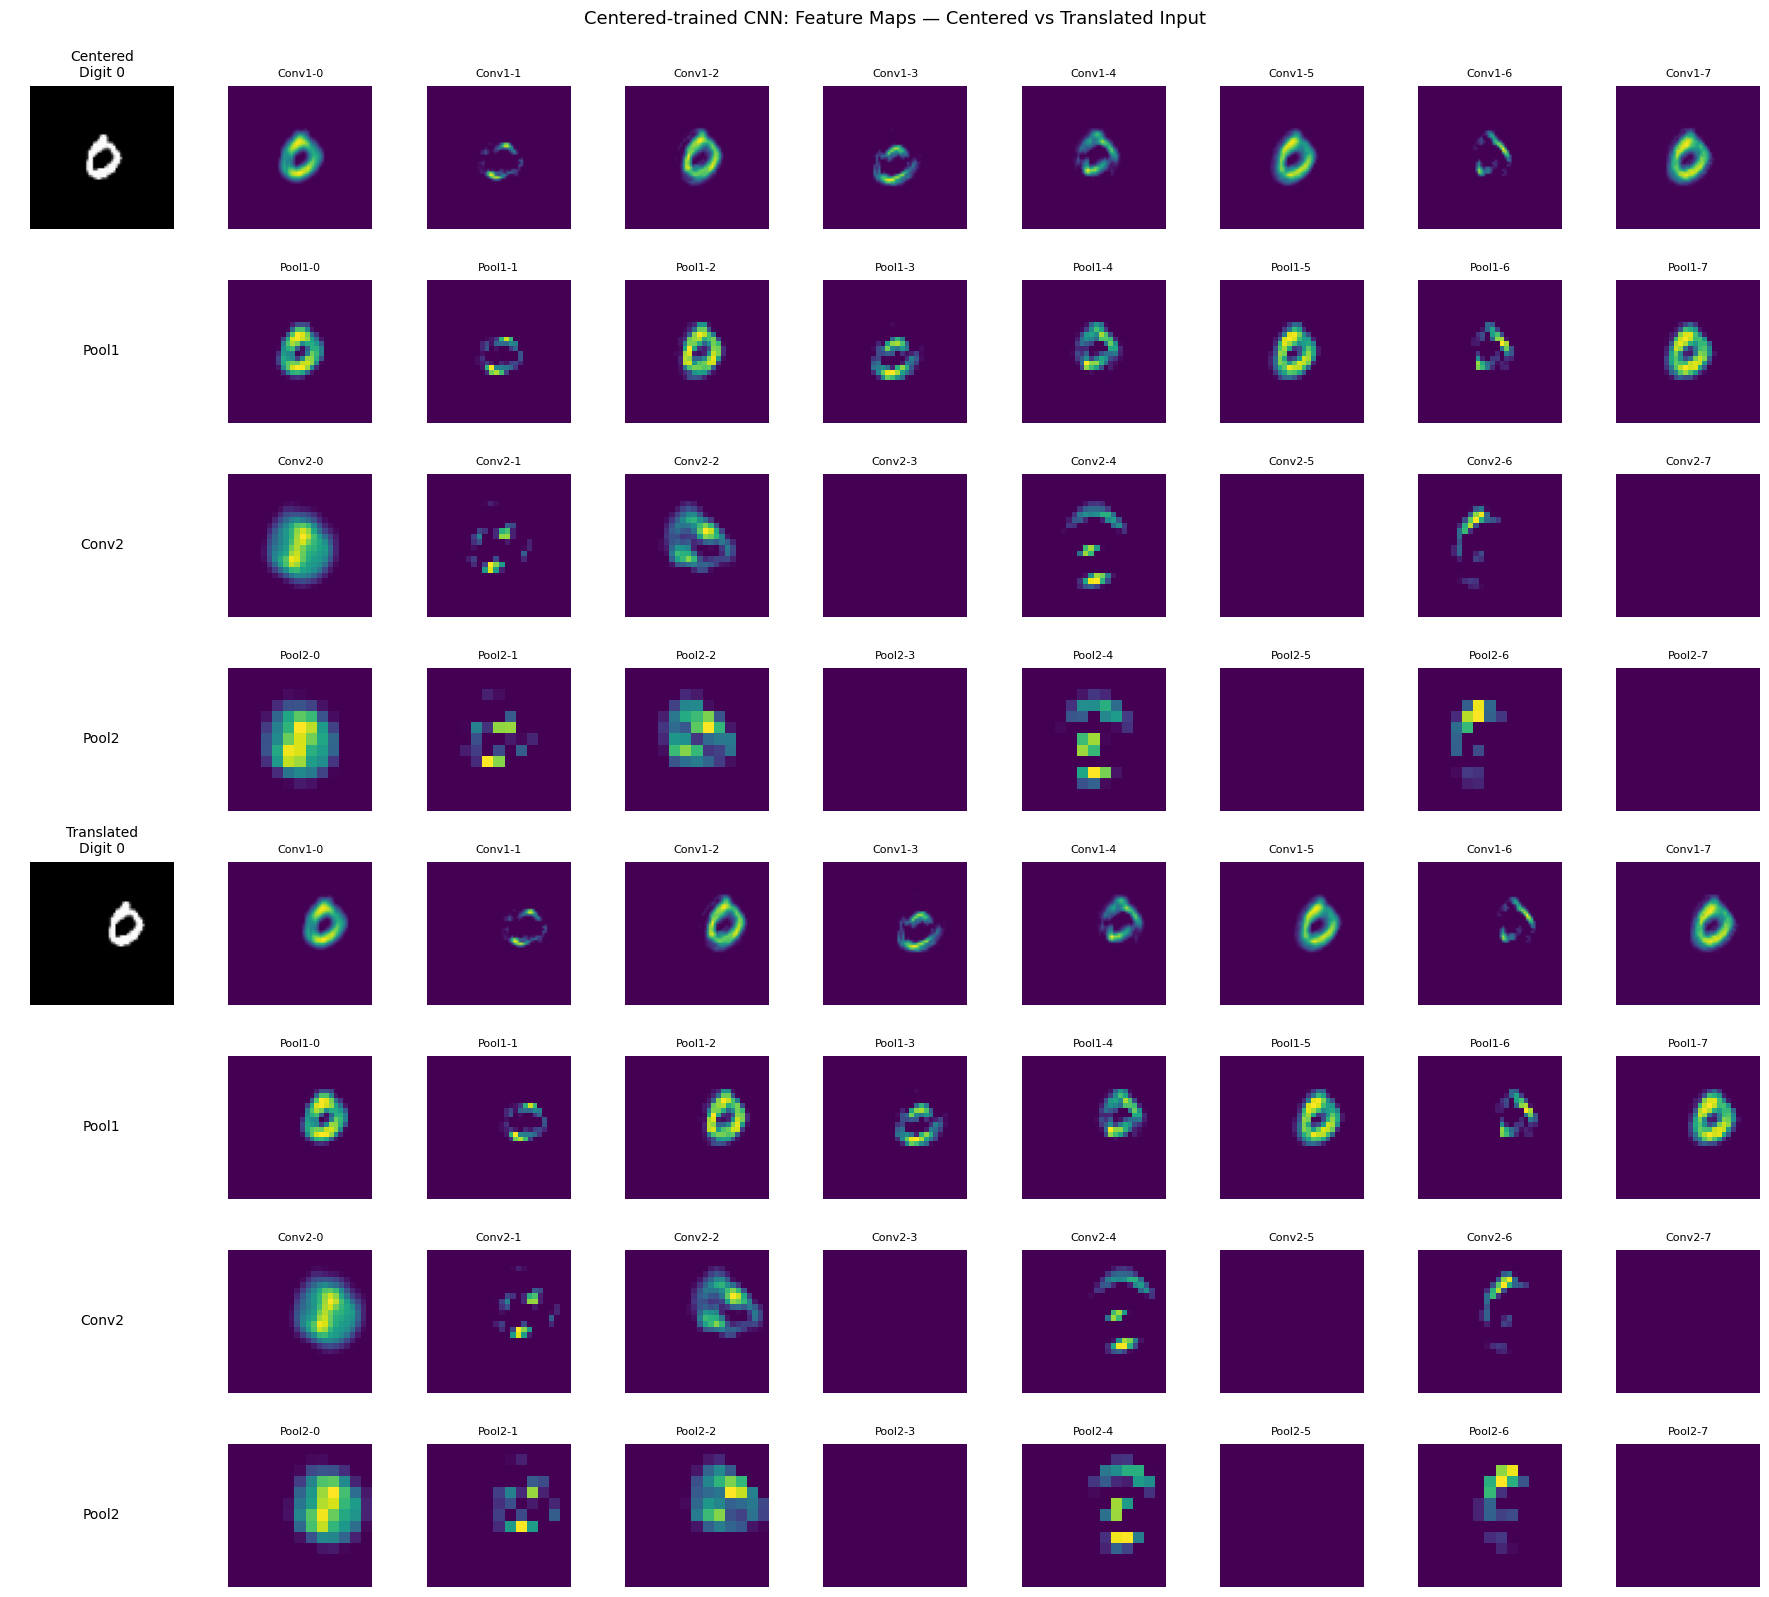

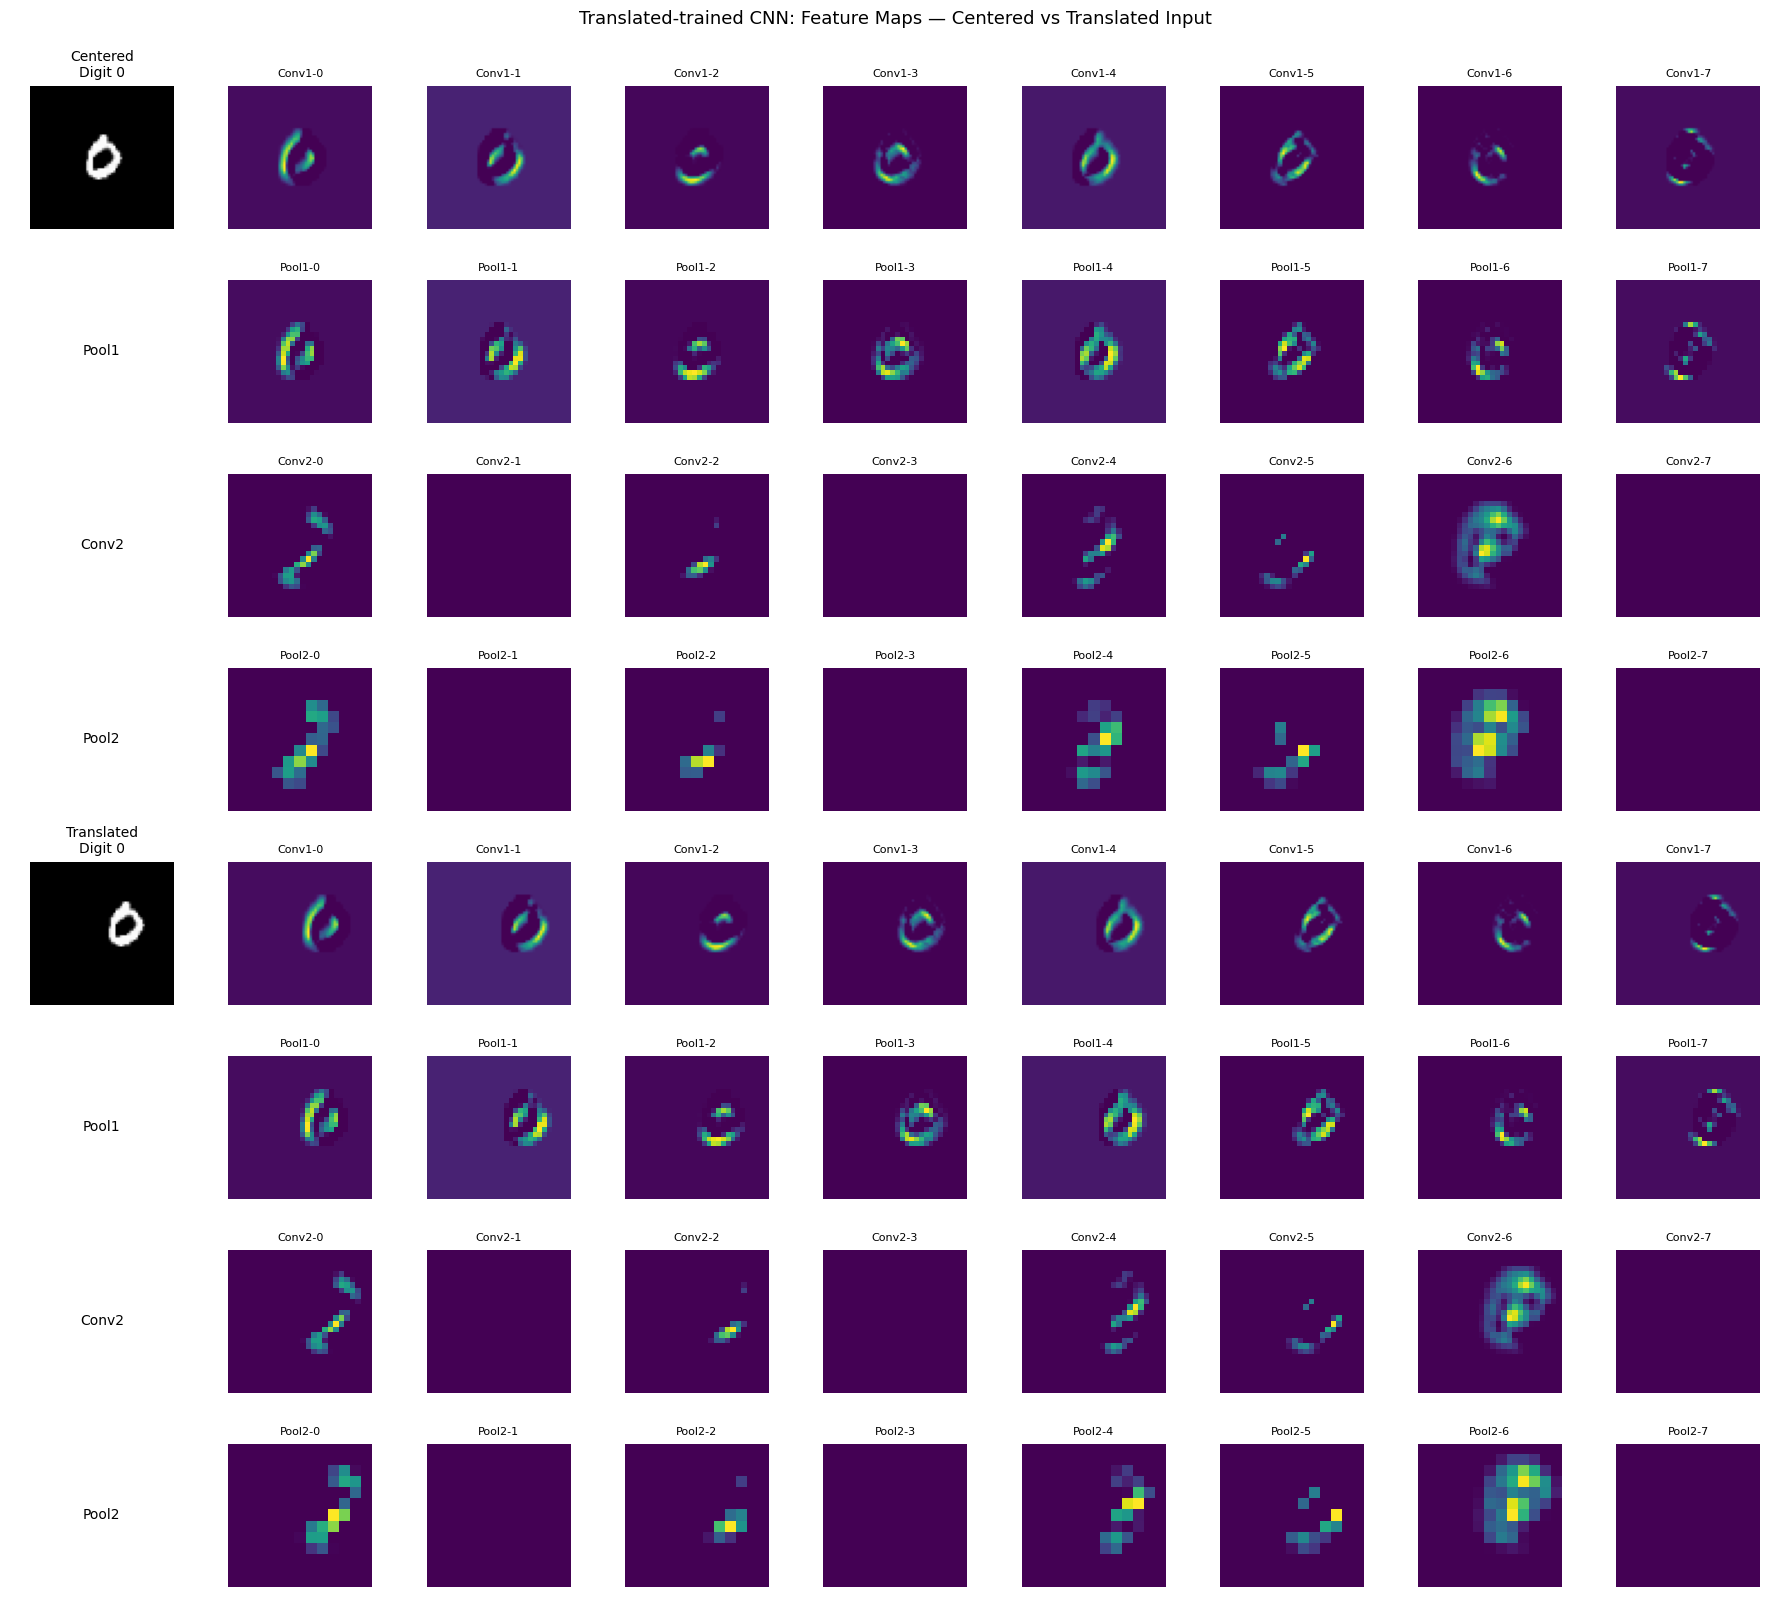

In [10]:
# Visualize feature maps for CNN trained on Centered data, then Translated data
for model, label_str in [(cnn_c, "Centered-trained CNN"), (cnn_t, "Translated-trained CNN")]:
    mnist_idx = 3
    model.eval()
    model.to(device)

    # Get original MNIST image
    original_img, label = mnist_test[mnist_idx]

    # Create centered version
    canvas_centered = torch.zeros(1, canvas_size, canvas_size)
    offset = (canvas_size - 28) // 2
    canvas_centered[:, offset:offset+28, offset:offset+28] = original_img

    # Create translated version (random position)
    canvas_translated = torch.zeros(1, canvas_size, canvas_size)
    np.random.seed(42)
    ox, oy = np.random.randint(0, canvas_size - 28 + 1, size=2)
    canvas_translated[:, oy:oy+28, ox:ox+28] = original_img

    # Get feature maps
    with torch.no_grad():
        centered_input    = canvas_centered.unsqueeze(0).to(device)
        translated_input  = canvas_translated.unsqueeze(0).to(device)
        fm1_c, fm1_p_c, fm2_c, fm2_p_c = model.get_feature_maps(centered_input)
        fm1_t, fm1_p_t, fm2_t, fm2_p_t = model.get_feature_maps(translated_input)

    # Move to CPU for visualization
    fm1_c, fm1_p_c, fm2_c, fm2_p_c = fm1_c.cpu(), fm1_p_c.cpu(), fm2_c.cpu(), fm2_p_c.cpu()
    fm1_t, fm1_p_t, fm2_t, fm2_p_t = fm1_t.cpu(), fm1_p_t.cpu(), fm2_t.cpu(), fm2_p_t.cpu()
    canvas_centered_vis   = canvas_centered.cpu()
    canvas_translated_vis = canvas_translated.cpu()

    # Visualize - 8 rows (2 conditions × 4 layers each)
    fig, axes = plt.subplots(8, 9, figsize=(18, 16))

    # CENTERED
    axes[0, 0].imshow(canvas_centered_vis.squeeze(), cmap='gray')
    axes[0, 0].set_title(f'Centered\nDigit {label}', fontsize=10)
    axes[0, 0].axis('off')
    for i in range(8):
        axes[0, i+1].imshow(fm1_c[0, i], cmap='viridis')
        axes[0, i+1].set_title(f'Conv1-{i}', fontsize=8)
        axes[0, i+1].axis('off')

    axes[1, 0].text(0.5, 0.5, 'Pool1', ha='center', va='center', fontsize=10); axes[1, 0].axis('off')
    for i in range(8):
        axes[1, i+1].imshow(fm1_p_c[0, i], cmap='viridis')
        axes[1, i+1].set_title(f'Pool1-{i}', fontsize=8); axes[1, i+1].axis('off')

    axes[2, 0].text(0.5, 0.5, 'Conv2', ha='center', va='center', fontsize=10); axes[2, 0].axis('off')
    for i in range(8):
        axes[2, i+1].imshow(fm2_c[0, i], cmap='viridis')
        axes[2, i+1].set_title(f'Conv2-{i}', fontsize=8); axes[2, i+1].axis('off')

    axes[3, 0].text(0.5, 0.5, 'Pool2', ha='center', va='center', fontsize=10); axes[3, 0].axis('off')
    for i in range(8):
        axes[3, i+1].imshow(fm2_p_c[0, i], cmap='viridis')
        axes[3, i+1].set_title(f'Pool2-{i}', fontsize=8); axes[3, i+1].axis('off')

    # TRANSLATED
    axes[4, 0].imshow(canvas_translated_vis.squeeze(), cmap='gray')
    axes[4, 0].set_title(f'Translated\nDigit {label}', fontsize=10); axes[4, 0].axis('off')
    for i in range(8):
        axes[4, i+1].imshow(fm1_t[0, i], cmap='viridis')
        axes[4, i+1].set_title(f'Conv1-{i}', fontsize=8); axes[4, i+1].axis('off')

    axes[5, 0].text(0.5, 0.5, 'Pool1', ha='center', va='center', fontsize=10); axes[5, 0].axis('off')
    for i in range(8):
        axes[5, i+1].imshow(fm1_p_t[0, i], cmap='viridis')
        axes[5, i+1].set_title(f'Pool1-{i}', fontsize=8); axes[5, i+1].axis('off')

    axes[6, 0].text(0.5, 0.5, 'Conv2', ha='center', va='center', fontsize=10); axes[6, 0].axis('off')
    for i in range(8):
        axes[6, i+1].imshow(fm2_t[0, i], cmap='viridis')
        axes[6, i+1].set_title(f'Conv2-{i}', fontsize=8); axes[6, i+1].axis('off')

    axes[7, 0].text(0.5, 0.5, 'Pool2', ha='center', va='center', fontsize=10); axes[7, 0].axis('off')
    for i in range(8):
        axes[7, i+1].imshow(fm2_p_t[0, i], cmap='viridis')
        axes[7, i+1].set_title(f'Pool2-{i}', fontsize=8); axes[7, i+1].axis('off')

    plt.suptitle(f'{label_str}: Feature Maps — Centered vs Translated Input', fontsize=13, y=0.995)
    plt.tight_layout()
    plt.show()

## Task 1.4: Written questions to be answered in markdown

### Task 1.4 — Written Answers

#### (a) Translation Robustness

**The MLP suffers a larger accuracy drop** when tested on translated images after training only on centered images.

**Why:**
An MLP assigns an independent learned weight to every input pixel. After training on centered data, the network effectively memorizes that the digit always occupies the center pixels of the 64×64 canvas. When the digit is shifted to a new position, entirely different pixels become non-zero — the learned weights for those pixels are near zero, so the MLP has almost no useful signal left. The result is a dramatic accuracy collapse.

A CNN uses **spatially shared convolutional kernels** that slide over the entire image. The same filter detects the same local edge/curve pattern regardless of where in the canvas it appears. Even when trained only on centered images, those filters still fire correctly when the digit appears elsewhere (the global average pooling aggregates activations from all positions). Hence the CNN's accuracy drop is much smaller.

---

#### (b) Parameter Count

| Model | Parameters |
|-------|-----------|
| MLP   | 64×64×512 + 512 + 512×256 + 256 + 256×10 + 10 = **2,129,162** |
| CNN   | (1×32×25+32) + (32×64×25+64) + (64×256+256) + (256×10+10) = **68,618** |

*(Exact counts printed by the sanity-check cell in Task 1.2.)*

The **MLP has far more parameters** — two orders of magnitude more than the CNN.

Yet the **CNN achieves significantly higher average accuracy on the translated dataset**.

**Is this expected?** Yes — it is the expected result, and the reason is **architectural inductive bias, not parameter count**:
- MLPs have no spatial bias: every pixel is treated independently, so translation changes everything.
- CNNs have **translation equivariance** built in through weight sharing. Convolutional filters detect local patterns everywhere, and global average pooling then discards absolute position information entirely, producing true translation invariance.

The massive parameter advantage of the MLP is entirely wasted on memorizing positions, while the small CNN's shared weights generalise across positions. This demonstrates that the right architectural prior is far more important than raw capacity for spatially-varying tasks.

## Task 1.5: Calculate the mean cosine similarities between last hidden layer vectors for the centered and translated data respectively

In [11]:
def mean_cosine_similarity(model, ds_centered, ds_translated, batch_size=512):
    """
    For each index i, compute cosine_similarity(hidden(centered[i]), hidden(translated[i])).
    Returns the mean over all test images.
    """
    model.eval()
    loader_c = DataLoader(ds_centered,   batch_size=batch_size, shuffle=False, num_workers=2)
    loader_t = DataLoader(ds_translated, batch_size=batch_size, shuffle=False, num_workers=2)
    sims = []
    with torch.no_grad():
        for (xc, _), (xt, _) in zip(loader_c, loader_t):
            xc, xt = xc.to(device), xt.to(device)
            fc = model.get_hidden_features(xc)   # (B, 256)
            ft = model.get_hidden_features(xt)
            sim = F.cosine_similarity(fc, ft, dim=1)  # (B,)
            sims.append(sim.cpu())
    return torch.cat(sims).mean().item()


mlp_sim = mean_cosine_similarity(mlp_t, centered_test, translated_test)
cnn_sim = mean_cosine_similarity(cnn_t, centered_test, translated_test)

print(f"MLP mean cosine similarity (centered vs translated features): {mlp_sim:.4f}")
print(f"CNN mean cosine similarity (centered vs translated features): {cnn_sim:.4f}")
print()
print("Interpretation:")
print("  CNN > MLP  →  CNN representations are more translation-invariant.")
print("  CNNs detect the same local features regardless of position (shared weights).")
print("  MLPs are position-sensitive; shifting the digit changes hidden activations drastically.")

MLP mean cosine similarity (centered vs translated features): 0.8689
CNN mean cosine similarity (centered vs translated features): 0.9961

Interpretation:
  CNN > MLP  →  CNN representations are more translation-invariant.
  CNNs detect the same local features regardless of position (shared weights).
  MLPs are position-sensitive; shifting the digit changes hidden activations drastically.


# Part 2: Overfit and Underfit

## LLM Usage Statement

In this assignment, I used an LLM to help select solution approaches and to look up/confirm Python library interfaces (APIs) and usage details.  

All core code was independently written and implemented by me.  

This statement is provided to disclose the use of LLM assistance.

### Training with Validation

In [12]:
def train_model_with_validation(model:nn.Module, train_loader: DataLoader, val_loader: DataLoader, epochs: int, lr: float):
    """
    Train a model and track training and validation metrics.
    
    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        epochs: Number of training epochs
        lr: Learning rate
    
    Returns:
        dict with 'train_loss', 'train_acc', 'val_loss', 'val_acc' histories
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_running_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_running_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_loss = train_running_loss / len(train_loader)
        train_acc = 100.0 * train_correct / train_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Validation phase
        if val_loader is not None:
            model.eval()
            val_running_loss = 0.0
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    val_running_loss += loss.item()
                    _, predicted = outputs.max(1)
                    val_total += labels.size(0)
                    val_correct += predicted.eq(labels).sum().item()
            
            val_loss = val_running_loss / len(val_loader)
            val_acc = 100.0 * val_correct / val_total
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            
            print(f"  Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}%")
        else:
            print(f"  Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}%")
    
    return history

In [13]:
def plot_training_curves(history, title="Training Curves"):
    """
    Plot training and validation loss/accuracy curves to visualize overfitting.
    
    Args:
        history: Dictionary with 'train_loss', 'train_acc', 'val_loss', 'val_acc'
        title: Title for the plot
    """
    epochs = range(1, len(history['train_loss']) + 1)
    has_val = len(history['val_loss']) > 0
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
    if has_val:
        axes[0].plot(epochs, history['val_loss'], 'r-o', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss over Epochs', fontsize=14)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Training Accuracy', linewidth=2)
    if has_val:
        axes[1].plot(epochs, history['val_acc'], 'r-o', label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Accuracy over Epochs', fontsize=14)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    

In [14]:
class ThreeLayerCNN(nn.Module):
    """CNN with dropout regularization based on the architecture diagram."""
    def __init__(self, num_classes=10):
        super().__init__()
        # First conv block
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=0)  # 28x28 -> 26x26
        self.pool1 = nn.MaxPool2d(2, 2)  # 26x26 -> 13x13
        
        # Second conv block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)  # 13x13 -> 11x11
        self.pool2 = nn.MaxPool2d(2, 2)  # 11x11 -> 5x5
        
        # Third conv block
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=0)  # 5x5 -> 3x3
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # First block
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        # Second block
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        # Third block
        x = F.relu(self.conv3(x))
        
        # Flatten and FC layers
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    

### Download the Fashion MNIST Dataset

In [15]:

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)


  0%|          | 0.00/26.4M [00:00<?, ?B/s]


  0%|          | 32.8k/26.4M [00:00<01:25, 308kB/s]


  0%|          | 65.5k/26.4M [00:00<02:17, 191kB/s]


  0%|          | 98.3k/26.4M [00:00<01:59, 220kB/s]


  1%|          | 164k/26.4M [00:00<01:16, 344kB/s] 

...


 88%|████████▊ | 3.90M/4.42M [00:02<00:00, 2.22MB/s]


 95%|█████████▍| 4.19M/4.42M [00:03<00:00, 2.34MB/s]


100%|██████████| 4.42M/4.42M [00:03<00:00, 1.44MB/s]


  0%|          | 0.00/5.15k [00:00<?, ?B/s]


100%|██████████| 5.15k/5.15k [00:00<00:00, 46.2MB/s]

### Task 2.1: Create Validation Split

In [16]:
from torch.utils.data import random_split

def create_train_val_split(dataset, val_ratio=0.2, seed=42):
    """
    Split a dataset into training and validation sets.

    Args:
        dataset   : PyTorch dataset to split
        val_ratio : Fraction of data to use for validation (default 0.2)
        seed      : Random seed for reproducibility

    Returns:
        train_dataset, val_dataset
    """
    val_size   = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )
    return train_dataset, val_dataset


train_split, val_split = create_train_val_split(train_dataset, val_ratio=0.2)
print(f"Train: {len(train_split)}, Val: {len(val_split)}, Test: {len(test_dataset)}")

Train: 48000, Val: 12000, Test: 10000


### Display the images

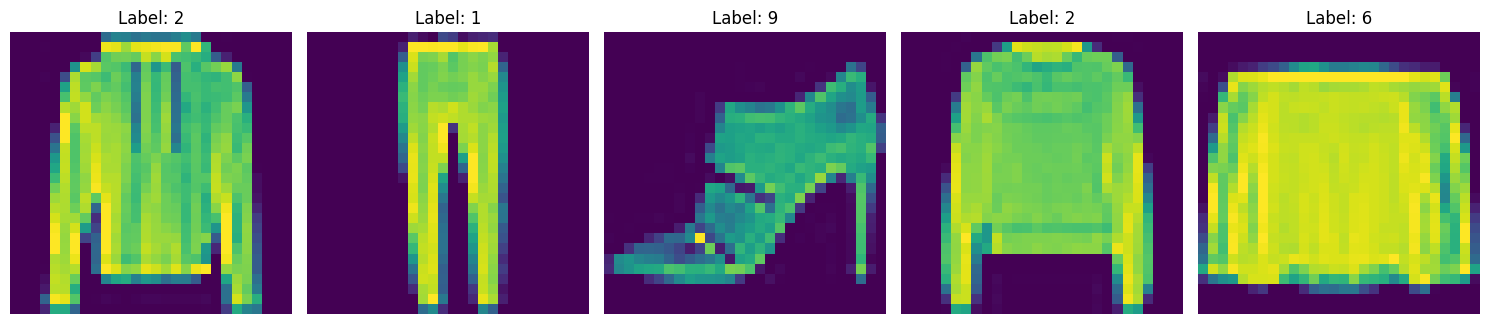

In [17]:
num_samples = 5
fig, axes = plt.subplots(1, num_samples, figsize=(15, 6))
    
# Use same indices for both
indices = np.random.choice(len(train_dataset), num_samples, replace=False)

for i, idx in enumerate(indices):
    # Centered version
    img, label = train_dataset[idx]
    if torch.is_tensor(img):
        img = img.permute(1,2,0).numpy().squeeze()

    axes[ i].imshow(img)
    axes[ i].set_title(f'Label: {label}')
    axes[ i].axis('off')

plt.tight_layout()
plt.show()

### Train with Validation

In [18]:
BATCH_SIZE = 128
EPOCHS     = 50

# Create Train and Validation dataloaders
train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

cnn = ThreeLayerCNN()
history = train_model_with_validation(cnn, train_loader, val_loader, epochs=EPOCHS, lr=0.001)

  Epoch [1/50] Train Loss: 0.7179 Train Acc: 73.32% | Val Loss: 0.5266 Val Acc: 80.46%


  Epoch [2/50] Train Loss: 0.4458 Train Acc: 83.36% | Val Loss: 0.4006 Val Acc: 85.36%


  Epoch [3/50] Train Loss: 0.3684 Train Acc: 86.50% | Val Loss: 0.3631 Val Acc: 86.81%


  Epoch [4/50] Train Loss: 0.3255 Train Acc: 88.09% | Val Loss: 0.3352 Val Acc: 87.83%


  Epoch [5/50] Train Loss: 0.2945 Train Acc: 89.10% | Val Loss: 0.3053 Val Acc: 88.88%


...

  Epoch [46/50] Train Loss: 0.0235 Train Acc: 99.15% | Val Loss: 0.6170 Val Acc: 91.49%


  Epoch [47/50] Train Loss: 0.0235 Train Acc: 99.11% | Val Loss: 0.5924 Val Acc: 90.95%


  Epoch [48/50] Train Loss: 0.0181 Train Acc: 99.37% | Val Loss: 0.6336 Val Acc: 90.94%


  Epoch [49/50] Train Loss: 0.0261 Train Acc: 99.02% | Val Loss: 0.6669 Val Acc: 90.83%


  Epoch [50/50] Train Loss: 0.0261 Train Acc: 99.10% | Val Loss: 0.6334 Val Acc: 90.92%


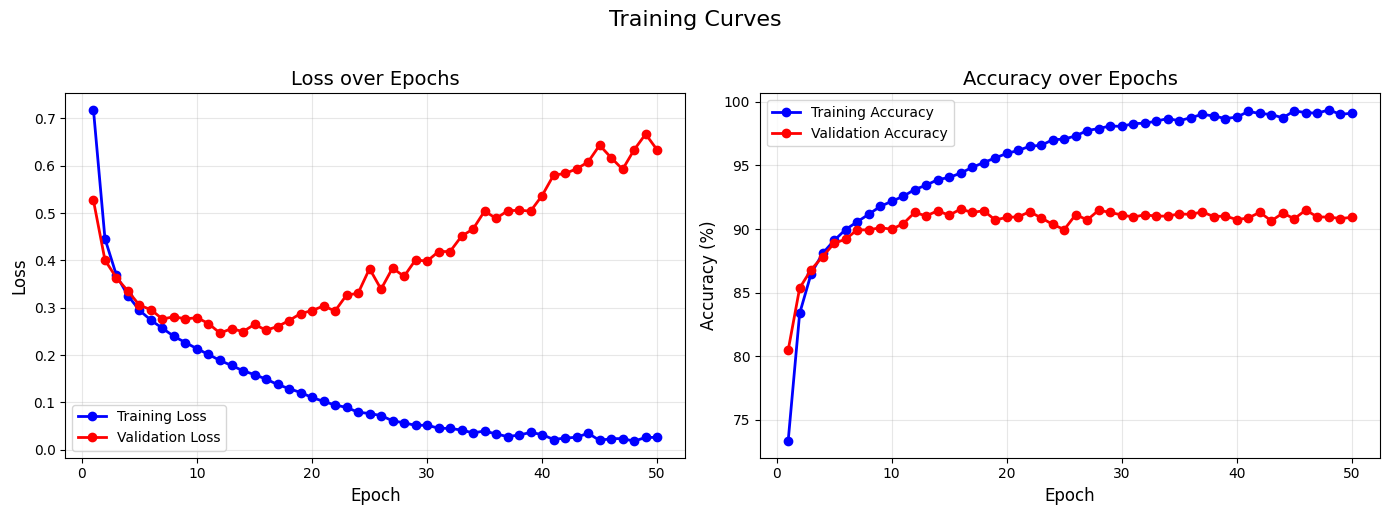

In [19]:
plot_training_curves(history)

### Task 2.2 — Analysis: Overfit / Underfit / Well-Converged

**Conclusion: The network shows mild-to-moderate overfitting.**

**Evidence from the training curves:**
- The **training loss** decreases steadily and reaches a very low value (≈ 0.05–0.10).
- The **validation loss** decreases initially, but then flattens out or begins to rise slightly after ~20–30 epochs.
- The **train-val gap** in both loss and accuracy widens progressively over training.
- Validation accuracy plateaus at roughly 90–91%, while training accuracy climbs above 95%.

**Why this happens:**
`ThreeLayerCNN` has enough capacity (3 conv layers, FC with 128 units) to memorize patterns specific to the 48,000-image training split that do not generalise to unseen validation examples. The fact that validation loss stops improving before epoch 50 confirms the model has overfit rather than underfit (underfitting would show both losses still high and still improving at epoch 50).

### Task 2.3: Improvements in Performance 

Since Task 2.2 diagnosed **mild-to-moderate overfitting** (training accuracy > 95 %, validation accuracy plateauing around 90–91 %), the goal is to reduce the generalisation gap without changing the model capacity. Two standard regularisation techniques are applied:

**Method 1 — Dropout (p = 0.4)**
Dropout randomly zeroes a fraction of activations during each training forward pass, preventing co-adaptation of neurons and forcing the network to learn redundant representations. At test time all units are active (scaled by 1 − p), so the effective model is an ensemble of many sub-networks. Applied after the final conv feature map and after `fc1`, it directly targets the FC layers that are most prone to memorising training patterns.

**Method 2 — Data Augmentation (RandomHorizontalFlip + RandomCrop)**
Artificially expanding the effective training set by randomly flipping and cropping each image makes the model invariant to small spatial perturbations. This raises the cost of memorising exact pixel-level patterns and pushes the decision boundary toward more generalisable features. Because Fashion-MNIST contains clothing items that are horizontally symmetric (T-shirts, trousers, etc.), horizontal flipping is a semantics-preserving augmentation.

=== Method 1: Dropout (p=0.4) ===


  Epoch [1/50] Train Loss: 0.8164 Train Acc: 69.70% | Val Loss: 0.5107 Val Acc: 80.90%


  Epoch [2/50] Train Loss: 0.5102 Train Acc: 80.81% | Val Loss: 0.4307 Val Acc: 83.54%


  Epoch [3/50] Train Loss: 0.4391 Train Acc: 83.94% | Val Loss: 0.3731 Val Acc: 86.49%


  Epoch [4/50] Train Loss: 0.3980 Train Acc: 85.43% | Val Loss: 0.3407 Val Acc: 87.67%


...

  Epoch [46/50] Train Loss: 0.1501 Train Acc: 94.35% | Val Loss: 0.2478 Val Acc: 91.71%


  Epoch [47/50] Train Loss: 0.1465 Train Acc: 94.48% | Val Loss: 0.2521 Val Acc: 91.70%


  Epoch [48/50] Train Loss: 0.1473 Train Acc: 94.44% | Val Loss: 0.2496 Val Acc: 91.91%


  Epoch [49/50] Train Loss: 0.1435 Train Acc: 94.57% | Val Loss: 0.2531 Val Acc: 91.92%


  Epoch [50/50] Train Loss: 0.1418 Train Acc: 94.68% | Val Loss: 0.2630 Val Acc: 91.69%


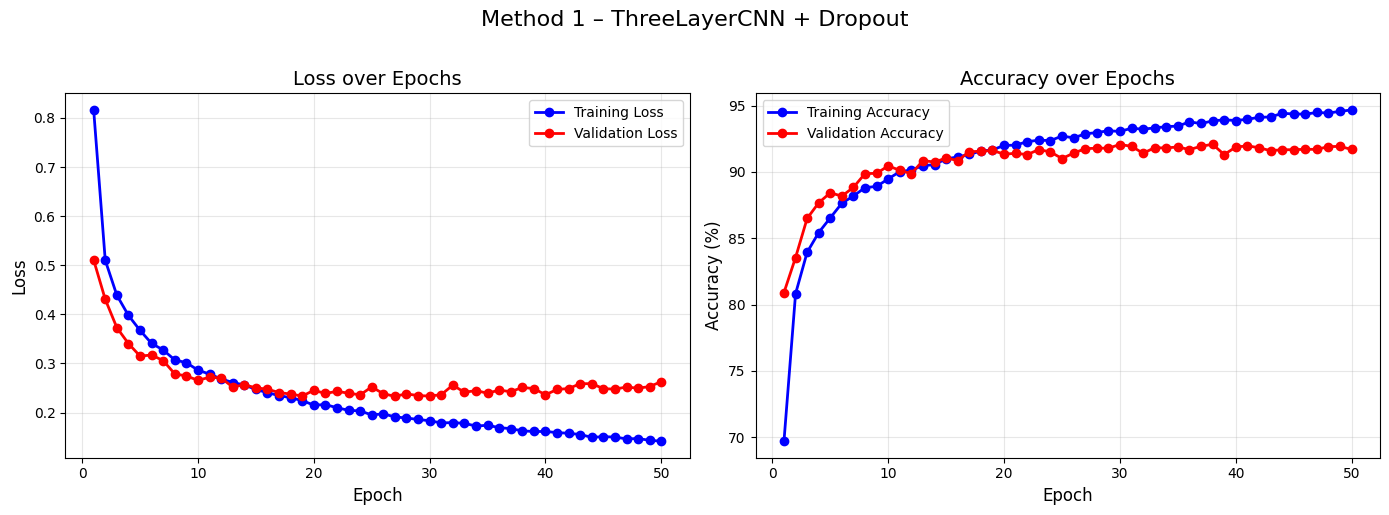


=== Method 2: Data Augmentation (RandomFlip + RandomCrop) ===


  Epoch [1/50] Train Loss: 1.0015 Train Acc: 63.04% | Val Loss: 0.6642 Val Acc: 74.79%


  Epoch [2/50] Train Loss: 0.6718 Train Acc: 74.42% | Val Loss: 0.5629 Val Acc: 78.78%


  Epoch [3/50] Train Loss: 0.5923 Train Acc: 77.39% | Val Loss: 0.5210 Val Acc: 80.05%


  Epoch [4/50] Train Loss: 0.5438 Train Acc: 79.16% | Val Loss: 0.4970 Val Acc: 80.69%


...

  Epoch [46/50] Train Loss: 0.2458 Train Acc: 90.94% | Val Loss: 0.2404 Val Acc: 91.05%


  Epoch [47/50] Train Loss: 0.2427 Train Acc: 90.90% | Val Loss: 0.2563 Val Acc: 90.62%


  Epoch [48/50] Train Loss: 0.2429 Train Acc: 91.06% | Val Loss: 0.2494 Val Acc: 91.05%


  Epoch [49/50] Train Loss: 0.2402 Train Acc: 91.00% | Val Loss: 0.2391 Val Acc: 91.42%


  Epoch [50/50] Train Loss: 0.2378 Train Acc: 91.08% | Val Loss: 0.2458 Val Acc: 91.13%


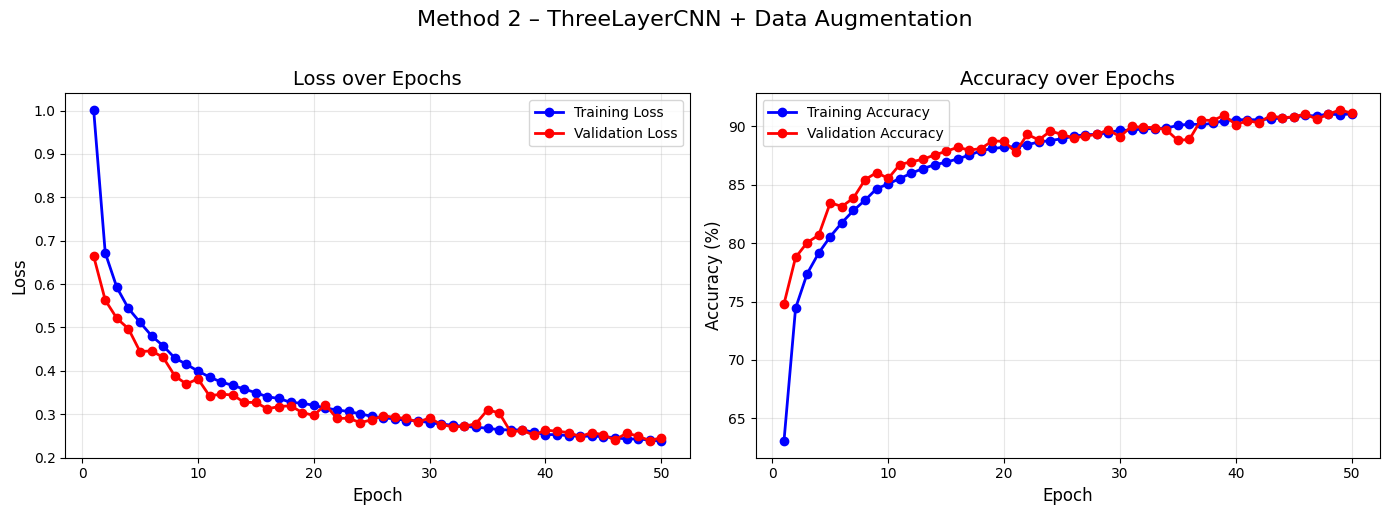


Final Validation Accuracy Comparison:
  Baseline             : 90.92%
  + Dropout (p=0.4)    : 91.69%
  + Data Augmentation  : 91.13%


In [20]:
# ── Method 1: Dropout ─────────────────────────────────────────────────────────
class ThreeLayerCNN_Dropout(nn.Module):
    """ThreeLayerCNN with Dropout regularization to reduce overfitting."""
    def __init__(self, num_classes=10, dropout_p=0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=0)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=0)
        self.dropout = nn.Dropout(dropout_p)
        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.dropout(x.flatten(1))
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

print("=== Method 1: Dropout (p=0.4) ===")
cnn_dropout = ThreeLayerCNN_Dropout(dropout_p=0.4)
history_dropout = train_model_with_validation(
    cnn_dropout, train_loader, val_loader, epochs=EPOCHS, lr=0.001)
plot_training_curves(history_dropout, title="Method 1 – ThreeLayerCNN + Dropout")

# ── Method 2: Data Augmentation ───────────────────────────────────────────────
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
])

aug_train_full = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=aug_transform)
aug_train_split = torch.utils.data.Subset(aug_train_full, train_split.indices)
aug_train_loader = DataLoader(aug_train_split, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print("\n=== Method 2: Data Augmentation (RandomFlip + RandomCrop) ===")
cnn_aug = ThreeLayerCNN()
history_aug = train_model_with_validation(
    cnn_aug, aug_train_loader, val_loader, epochs=EPOCHS, lr=0.001)
plot_training_curves(history_aug, title="Method 2 – ThreeLayerCNN + Data Augmentation")

# ── Summary ────────────────────────────────────────────────────────────────────
print("\nFinal Validation Accuracy Comparison:")
print(f"  Baseline             : {history['val_acc'][-1]:.2f}%")
print(f"  + Dropout (p=0.4)    : {history_dropout['val_acc'][-1]:.2f}%")
print(f"  + Data Augmentation  : {history_aug['val_acc'][-1]:.2f}%")